In [1]:
import pandas as pd
import random
import utils.llm as llm
import pickle

In [ ]:
dr_masked = pd.read_pickle('data/dr/text/leakage/dr_masked.pkl')
dr_masked

## Same score dict as in test 2

In [3]:
score_dict_2 = {
    "sty": "Style, precision, understandability, professionality and appropriateness of the text - 1: low quality of the text, stilistic issues, 10: well structured, fluent text with a guiding thread and no major errors",
    "tec": "Technical knowledge of the author - 1: author seems rather clueless in terms of technical details, 10: author knows all relevant technical specifics",
    "mak": "Market knowledge of the author - 1: the author doesn't adress market factors at all or very vaguely/incorrectly, 10: the author shows high market awareness and has a strategic approach towards product-market fit",
    "dow": "Down-to-earthness of the author - 1: extreme exaggerations and buzzword usage, 10: very down-to earth tone, realistic scenarios, no empty phrases and buzz words",
    "mar": "Market focus and clarity of the business case presented in the text - 1: no adressing of the market or unrealistic expectations, 10: high market awareness, strategic plan on marketing the product or service",
    "nov": "Novelty/originality of the business model presented in the text - 1: generic business idea that has been seen a lot, 10: novel and original business/product idea",
    "via": "Operational viability of the business model presented in the text - 1: unrealistic operational expecations and assumptions, 10: differentiated and nuanced business idea",
    "atr": "Attractiveness of the product or service presented in the text - 1: product or service that has little or no use for the customer, in relation to the expected price, 10: high utility of the product or service in relation to the price"
}

## New generate scores function
- removed the keyword part, as it is better understood that way (the reasoning is shorter)
- higher num_predict for qwen3, because thinking consumes tokens

In [4]:
def generate_scores_3(pitch_text, score_dict, model="mistral:7b-instruct-v0.3-q3_K_L", temp=0, seed=4, num_predict=1000, top_k=40, top_p=0.9):
    # Always define results first
    results = {}

    # Handle empty or None input
    if pitch_text is None or pd.isna(pitch_text) or str(pitch_text).lower() == 'nan' or pitch_text.strip() == "":
        for score_code in score_dict.keys():
            results[score_code] = {"score": None, "response": ""}
        return results

    try:
    
        prompt = f"""You are a critical VC investor tasked with evaluating a startup pitch.

START OF THE PITCH TEXT >>>
{pitch_text}
<<< END OF THE PITCH TEXT

Score the startup pitch above for the following dimensions:
{score_dict}

Provide a score out of the set [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] and a very short sentence for reasoning. Be very critical and only refer to above criteria. Utilize the full range of scores.

Return the score exactly in this format:
sty: X - Reason: [reasoning keywords or short sentence for reasoning here]
...
"""

        full_response = llm.prompt(
            prompt,
            model,
            temp=temp,
            seed=seed,
            num_predict=num_predict,
            top_k=top_k,
            top_p=top_p,
        ).strip()

        parsed_scores = llm.parse_all_scores(full_response, list(score_dict.keys()))

        for score_code in score_dict.keys():
            if score_code in parsed_scores:
                results[score_code] = {
                    "score": parsed_scores[score_code]["score"],
                    "response": parsed_scores[score_code]["line"],
                }
            else:
                results[score_code] = {
                    "score": None,
                    "response": "",
                }

    except Exception as e:
        print(f"Ollama call failed: {e}")
        for score_code in score_dict.keys():
            results[score_code] = {"score": None, "response": ""}

    return results

In [ ]:
text = """Test Text"""

In [6]:
#generate_scores_3(text, score_dict_2, model="llama3.1:8b")

## Scoring df, temp = 0

In [ ]:
# Map each model to a safe checkpoint name
models = {
    #"llama3.1:8b": "llama",
    "llama3.2:3b-instruct-fp16": "llama_instruct",
    #"mistral:7b": "mistral",
    #"mistral:7b-instruct-v0.3-q3_K_L": "mistral_instruct",
    "gemma3": "gemma3"
}

results_0 = {}

for model_name, checkpoint_name in models.items():
    print(f"\nRunning model: {model_name}")
    
    checkpoint_path = f"data/dr/text/scoring/local/{checkpoint_name}_temp0_scores_final.pkl"
    
    results_0[model_name] = llm.score_df(
        df=dr_masked,
        score_dict=score_dict_2,
        text_col="masked",
        generate_scores_func=generate_scores_3,
        model=model_name,
        generate_kwargs={"temp": 0},
        workers=2,
        checkpoint_file=checkpoint_path,
        save_frequency=10
    )

print("\nAll models finished.")


Running model: llama3.2:3b-instruct-fp16
Loaded checkpoint with 8789 processed items
Processing 0 remaining rows out of 8789 total
All rows already processed. Loading from checkpoint.

Running model: gemma3
Loaded checkpoint with 8789 processed items
Processing 0 remaining rows out of 8789 total
All rows already processed. Loading from checkpoint.

All models finished.


## Computation time
- l and li: 14s/it
- m and mi: 20s/it
- g3: 8s/it

# Merge all

In [8]:
from functools import reduce

# Define your DataFrames and their suffixes
dfs = {
    #'l_0': results_0['llama3.1:8b'],
    'li_0': results_0['llama3.2:3b-instruct-fp16'],
    #'m_0': results_0['mistral:7b'],
    #'mi_0': results_0['mistral:7b-instruct-v0.3-q3_K_L'],
    'g3_0': results_0['gemma3']
}

from functools import reduce
import pandas as pd

def merge_dfs_with_suffixes(dfs_dict, on='id'):
    dfs_renamed = []
    
    for i, (name, df) in enumerate(dfs_dict.items()):
        df_copy = df.copy()
        
        # Keep masked + name only from first dataframe
        if i != 0:
            df_copy = df_copy.drop(columns=['masked', 'name'], errors='ignore')
        
        # Rename all columns except id, masked, name
        df_copy = df_copy.rename(
            columns={
                c: f"{c}_{name}"
                for c in df_copy.columns
                if c not in [on, 'masked', 'name']
            }
        )
        
        dfs_renamed.append(df_copy)
    
    merged_df = reduce(
        lambda left, right: pd.merge(left, right, on=on, how='outer'),
        dfs_renamed
    )
    
    return merged_df

In [9]:
dr_scores = merge_dfs_with_suffixes(dfs, on='id')
dr_scores.columns

Index(['id', 'name', 'masked', 'sty_score_li_0', 'tec_score_li_0',
       'mak_score_li_0', 'dow_score_li_0', 'mar_score_li_0', 'nov_score_li_0',
       'via_score_li_0', 'atr_score_li_0', 'sty_response_li_0',
       'tec_response_li_0', 'mak_response_li_0', 'dow_response_li_0',
       'mar_response_li_0', 'nov_response_li_0', 'via_response_li_0',
       'atr_response_li_0', 'sty_score_g3_0', 'tec_score_g3_0',
       'mak_score_g3_0', 'dow_score_g3_0', 'mar_score_g3_0', 'nov_score_g3_0',
       'via_score_g3_0', 'atr_score_g3_0', 'sty_response_g3_0',
       'tec_response_g3_0', 'mak_response_g3_0', 'dow_response_g3_0',
       'mar_response_g3_0', 'nov_response_g3_0', 'via_response_g3_0',
       'atr_response_g3_0'],
      dtype='str')

In [ ]:
dr_scores.to_pickle('data/dr/text/scoring/dr_scores_local.pkl')

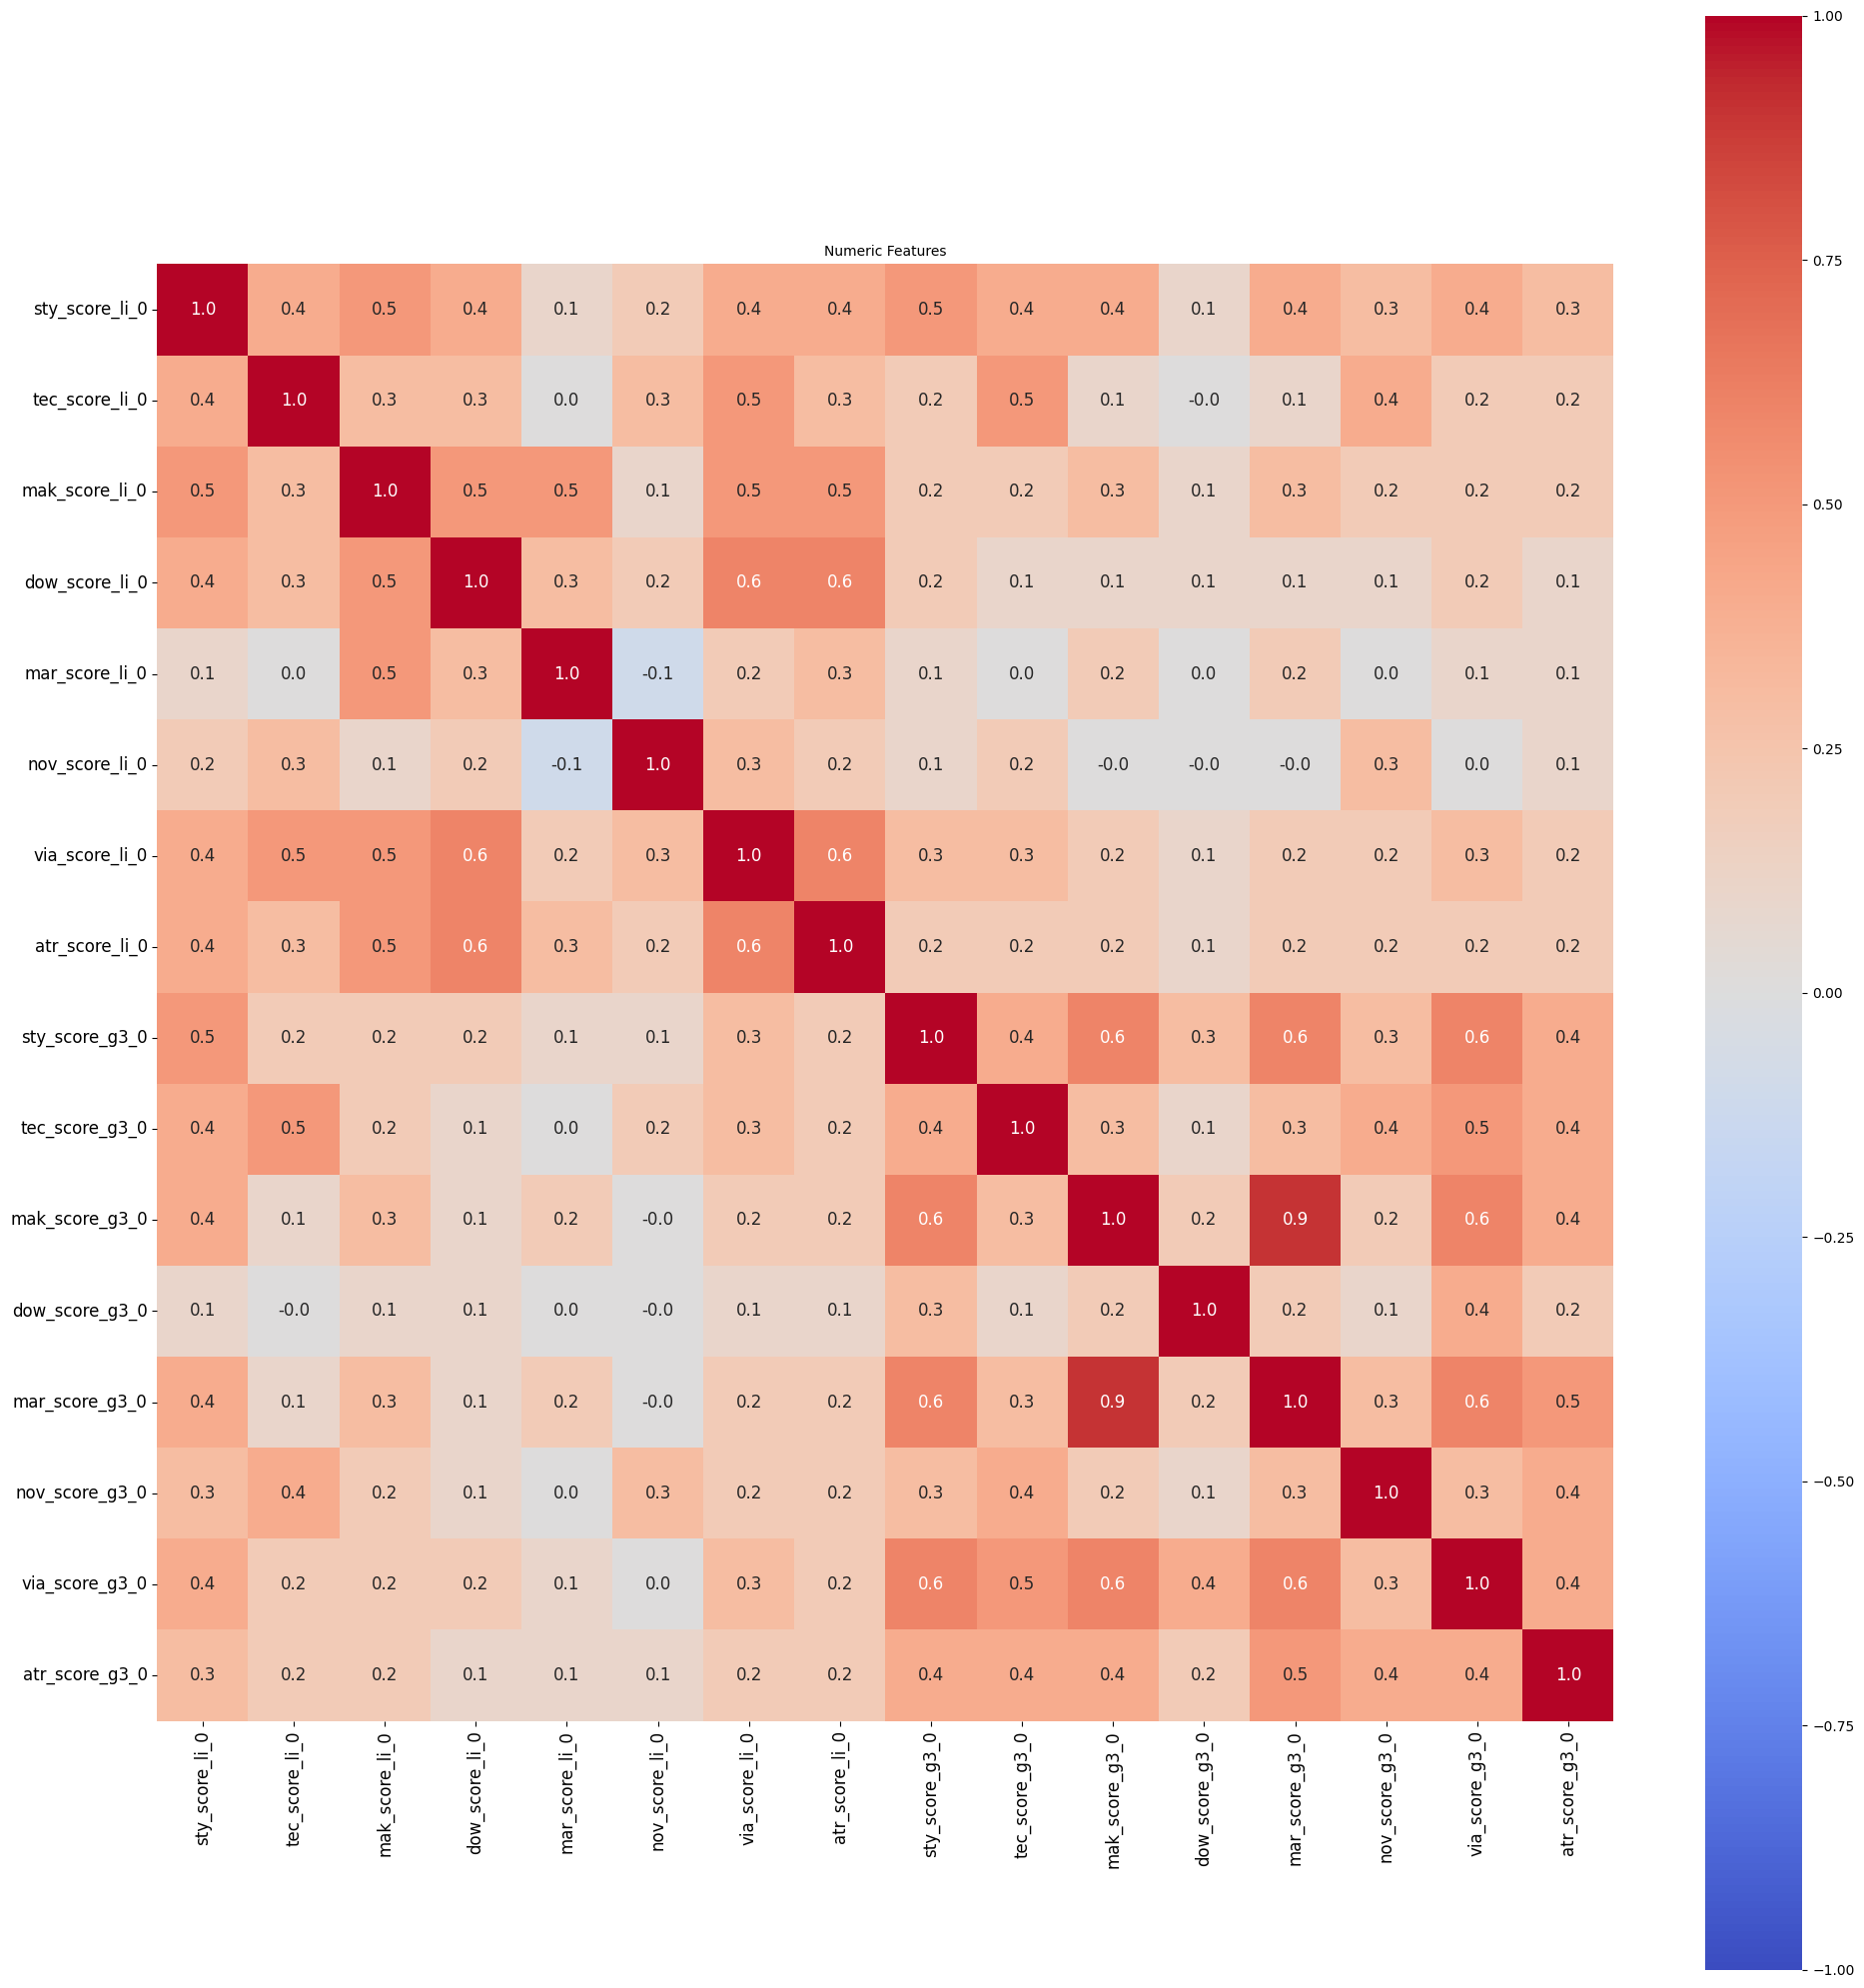

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation of numeric features
correlation_matrix = dr_scores.corr(numeric_only=True).round(1)

plt.figure(figsize=(20, 20))

ax = sns.heatmap(
    correlation_matrix,
    annot=True,
    annot_kws={"size": 12},
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    fmt='.1f',
    square=True
)

# Smaller axis tick labels
ax.tick_params(axis='both', labelsize=12)

# Smaller title
plt.title('Numeric Features', fontsize=10)

plt.tight_layout()
plt.show()

## Merge per model

In [12]:
from collections import defaultdict

def merge_same_model_dfs(dfs_dict, on='id'):
    # Group dfs by model prefix (before first underscore)
    grouped = defaultdict(dict)
    
    for key, df in dfs_dict.items():
        model_prefix = key.split('_')[0]  # l, li, m, mi, g3
        grouped[model_prefix][key] = df
    
    merged_models = {}
    
    for model, model_dfs in grouped.items():
        dfs_renamed = []
        
        for name, df in model_dfs.items():
            df_copy = df.copy()
            
            # Keep masked + name only from first dataframe
            if len(dfs_renamed) > 0:
                df_copy = df_copy.drop(columns=['masked', 'name'], errors='ignore')
            
            # Rename columns except id/masked/name
            df_copy = df_copy.rename(
                columns={
                    c: f"{c}_{name}"
                    for c in df_copy.columns
                    if c not in [on, 'masked', 'name']
                }
            )
            
            dfs_renamed.append(df_copy)
        
        merged_models[model] = reduce(
            lambda left, right: pd.merge(left, right, on=on, how='outer'),
            dfs_renamed
        )
    
    return merged_models

In [13]:
merged_by_model = merge_same_model_dfs(dfs)

## Plot per model

In [14]:
def plot_model_correlations(merged_models):
    for model_name, df in merged_models.items():
        # Select numeric columns only
        numeric_cols = df.select_dtypes(include='number').round(1)
        
        # Compute correlation
        corr = numeric_cols.corr()
        
        # Plot
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr, 
                    annot=True, 
                    fmt=".1f", 
                    cmap="coolwarm",
                    vmin=-1, vmax=1,
                    cbar=True,
                    annot_kws={'size': 8})  # Make annotation text smaller
        plt.title(f"Correlation Plot for Model: {model_name}")
        
        # Make axis labels smaller
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)
        
        plt.tight_layout()  # Adjust layout
        plt.show()

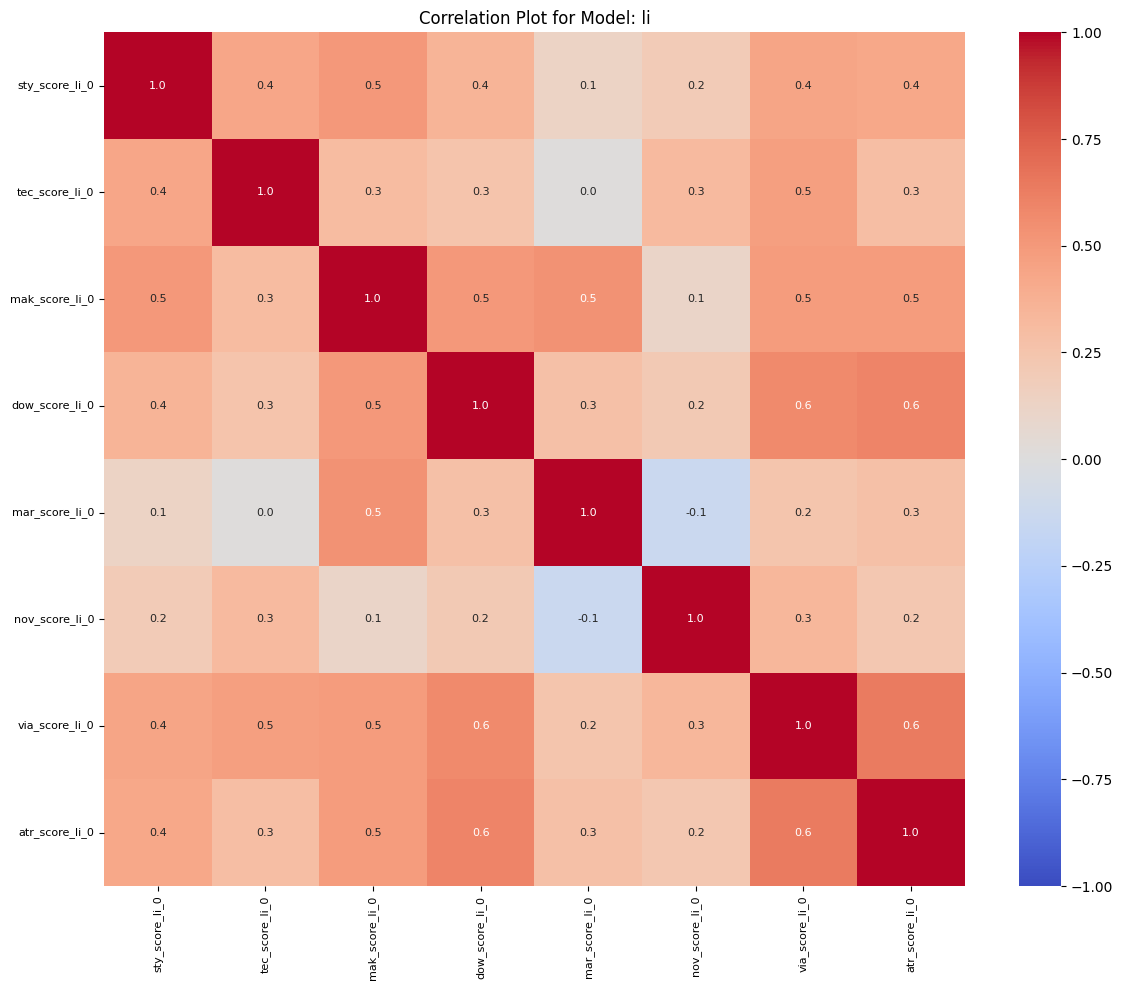

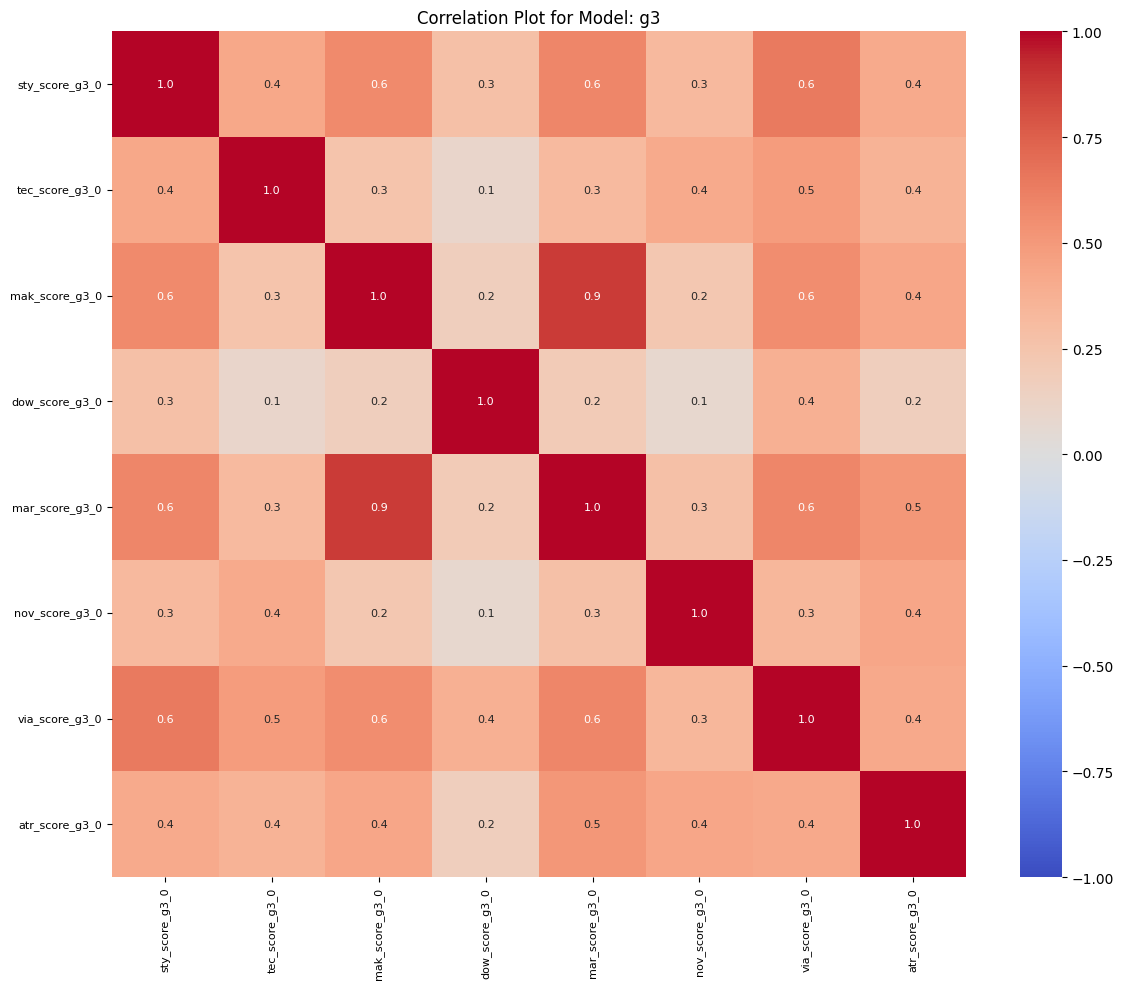

In [15]:
plot_model_correlations(merged_by_model)

## Plot per temperature


Temperature: 0
Looking for score columns with temperature: 0 (excluding _rev)
Found 16 score columns


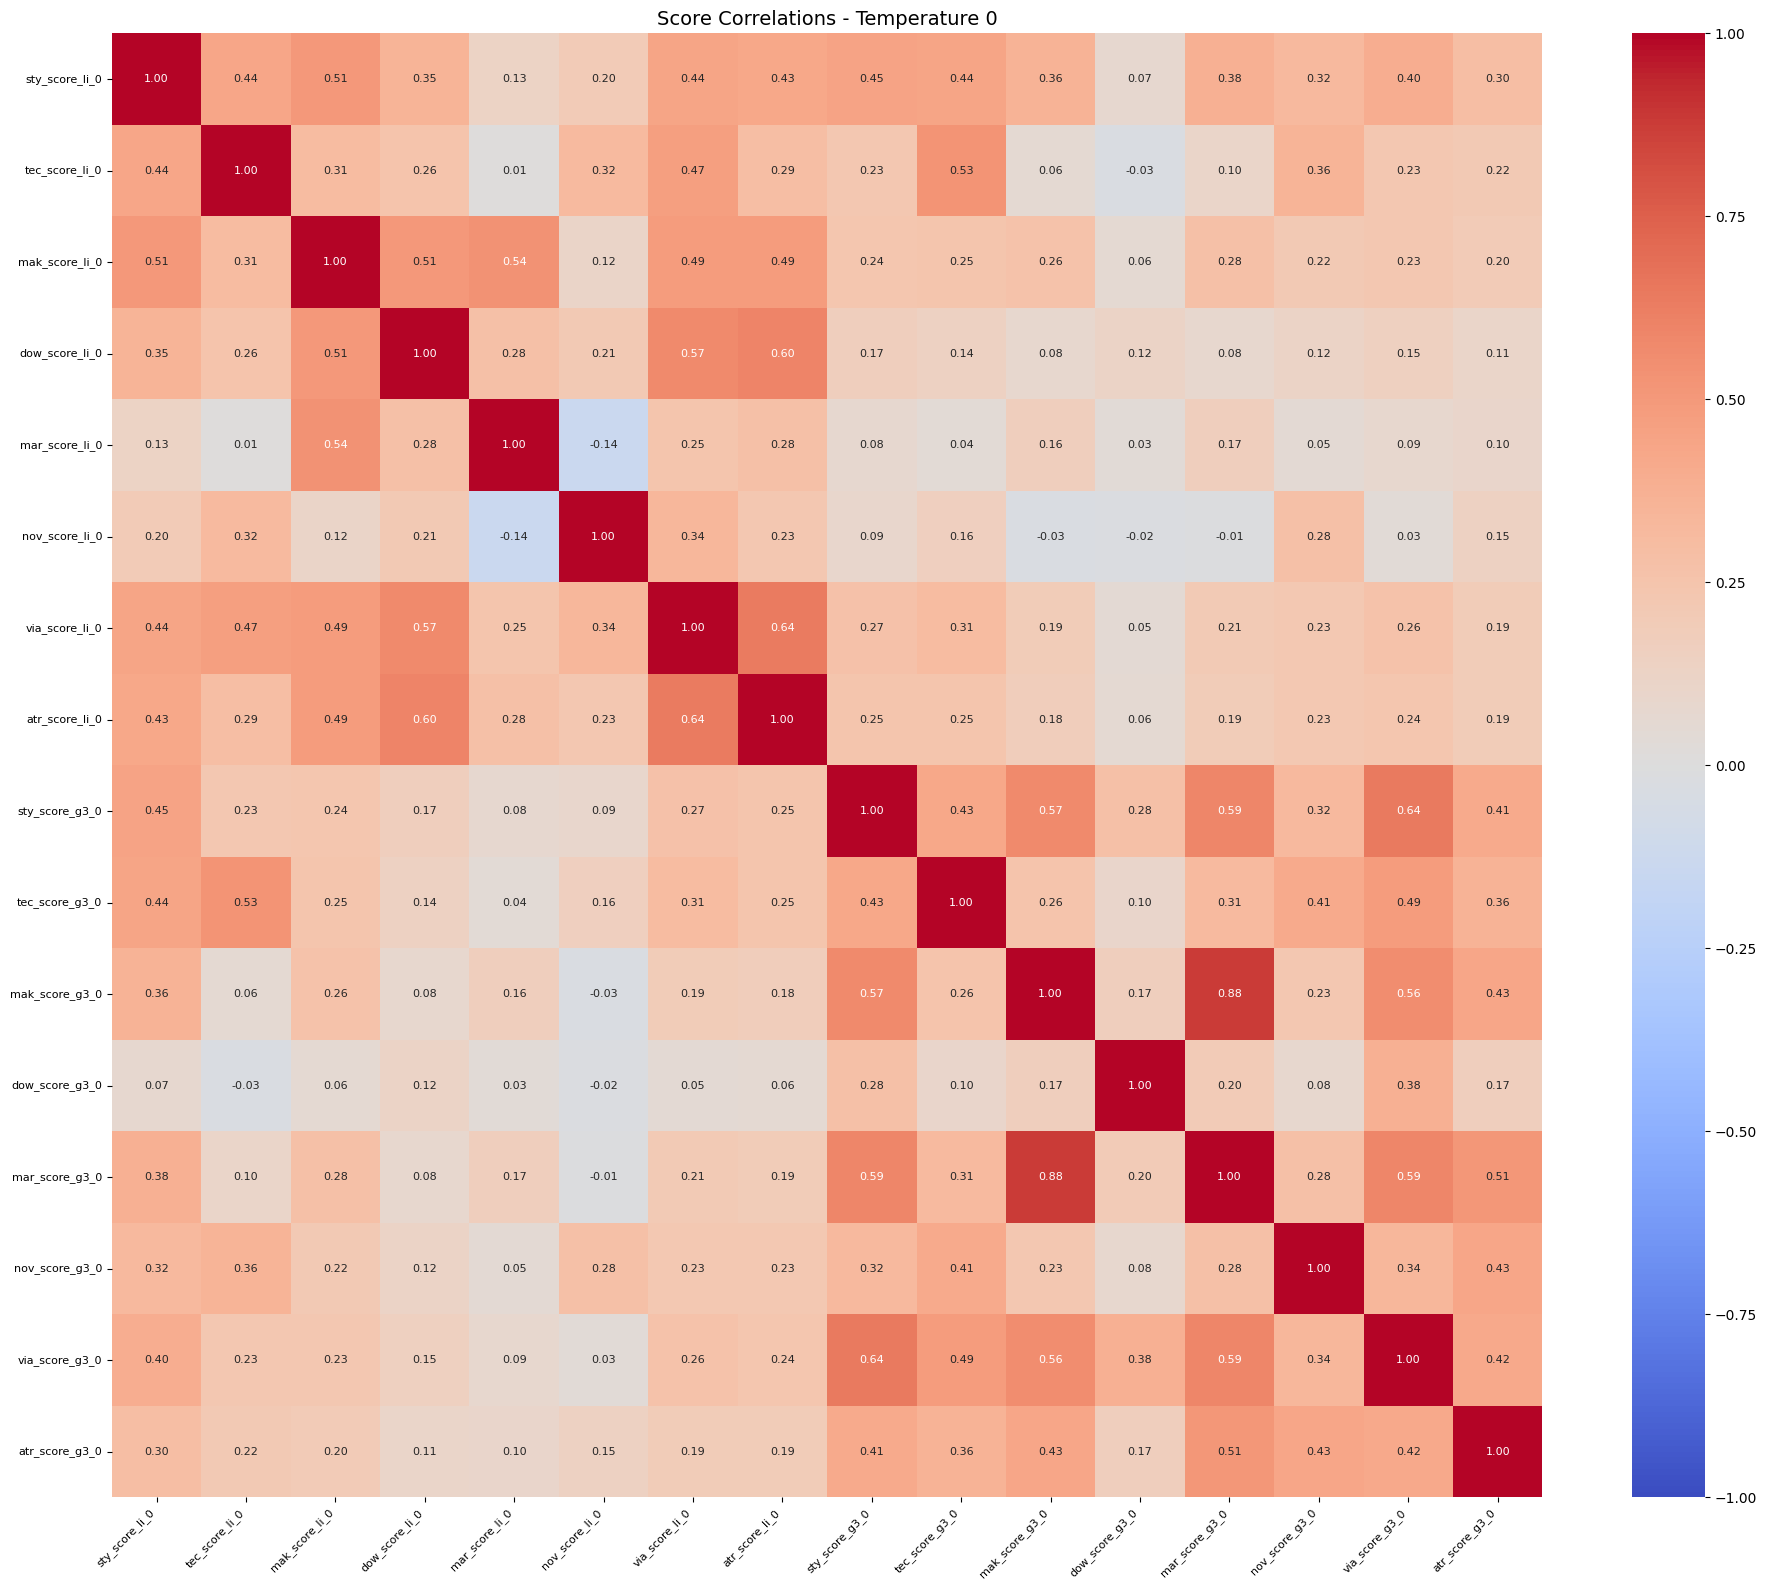

In [16]:
def plot_temperature_correlations(merged_models, temperature="1_2"):
    """
    Plot correlations for score columns at a specific temperature (excluding _rev)
    Returns: (combined_df, corr) or (None, None) if insufficient data
    """
    print(f"Looking for score columns with temperature: {temperature} (excluding _rev)")
    
    # Split the temperature into parts (e.g., "0_4" becomes ["0", "4"])
    temp_parts = temperature.split('_')
    
    # Find all score columns for this temperature that DON'T have '_rev'
    score_columns = []
    for col_name in merged_models.keys():
        if 'score' in col_name and '_rev' not in col_name:
            # Split the column name by underscore
            parts = col_name.split('_')
            
            # Check if the temperature parts match at the end of the parts list
            # This assumes temperature is always at the end of the column name
            if len(parts) >= len(temp_parts):
                # Get the last N parts where N is the length of temp_parts
                last_parts = parts[-len(temp_parts):]
                if last_parts == temp_parts:
                    score_columns.append(col_name)
    
    print(f"Found {len(score_columns)} score columns")
    
    if len(score_columns) < 2:
        print("Not enough score columns for correlation")
        return None, None
    
    # Create DataFrame with all score series, ensuring they're numeric
    df_list = []
    for col in score_columns:
        series = merged_models[col]
        # Convert to numeric, coercing errors to NaN
        series = pd.to_numeric(series, errors='coerce')
        df_list.append(series.rename(col))
    
    combined_df = pd.concat(df_list, axis=1)
    
    # Drop rows with all NaN
    combined_df = combined_df.dropna(how='all')
    
    if len(combined_df) < 2:
        print("Not enough valid data rows for correlation")
        return None, None
    
    # Compute correlation
    corr = combined_df.corr()
    
    # Plot with original column names
    plt.figure(figsize=(min(20, len(score_columns) * 1.2), 
                       min(16, len(score_columns) * 1.0)))
    
    sns.heatmap(corr, 
               annot=True, 
               fmt=".2f", 
               cmap="coolwarm", 
               vmin=-1, vmax=1,
               cbar=True,
               xticklabels=score_columns,  # Original column names
               yticklabels=score_columns,  # Original column names
               annot_kws={'size': 8})
    
    plt.title(f"Score Correlations - Temperature {temperature}", fontsize=14)
    plt.xticks(fontsize=8, rotation=45, ha='right')
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    return combined_df, corr

print("\n" + "="*50)
print("Temperature: 0")
print("="*50)
result_0 = plot_temperature_correlations(dr_scores, temperature="0")
if result_0[0] is not None:
    df_0, corr_0 = result_0
else:
    print("Could not generate correlation for temperature 0")
    df_0, corr_0 = None, None

## Plot per score


Looking for sty score columns (excluding _rev)


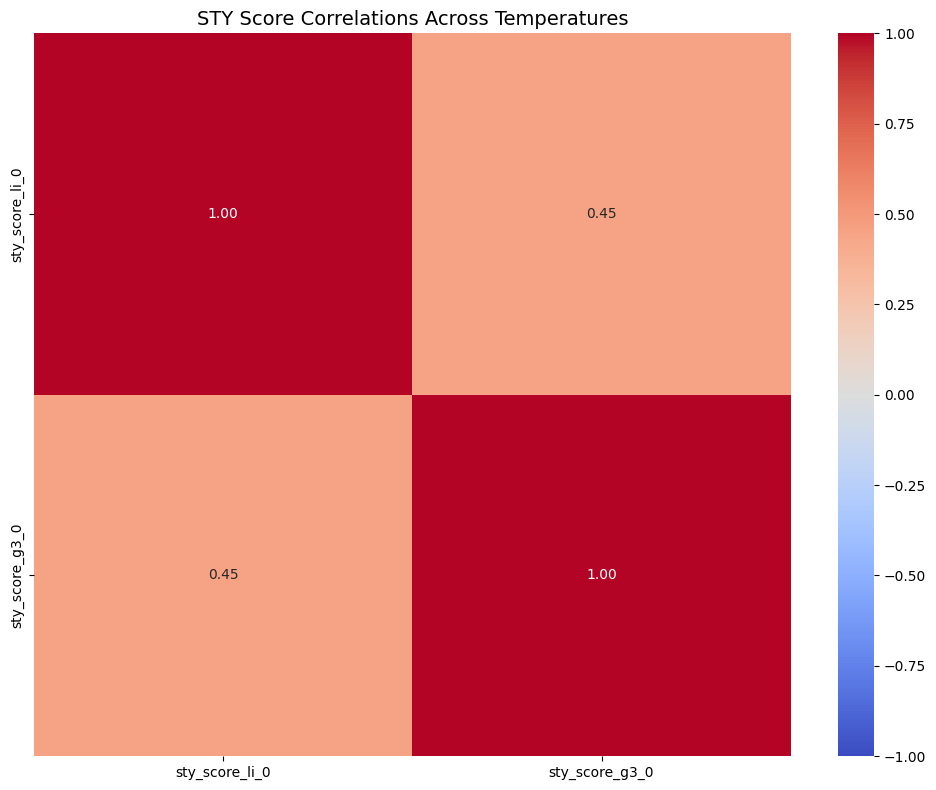


Looking for tec score columns (excluding _rev)


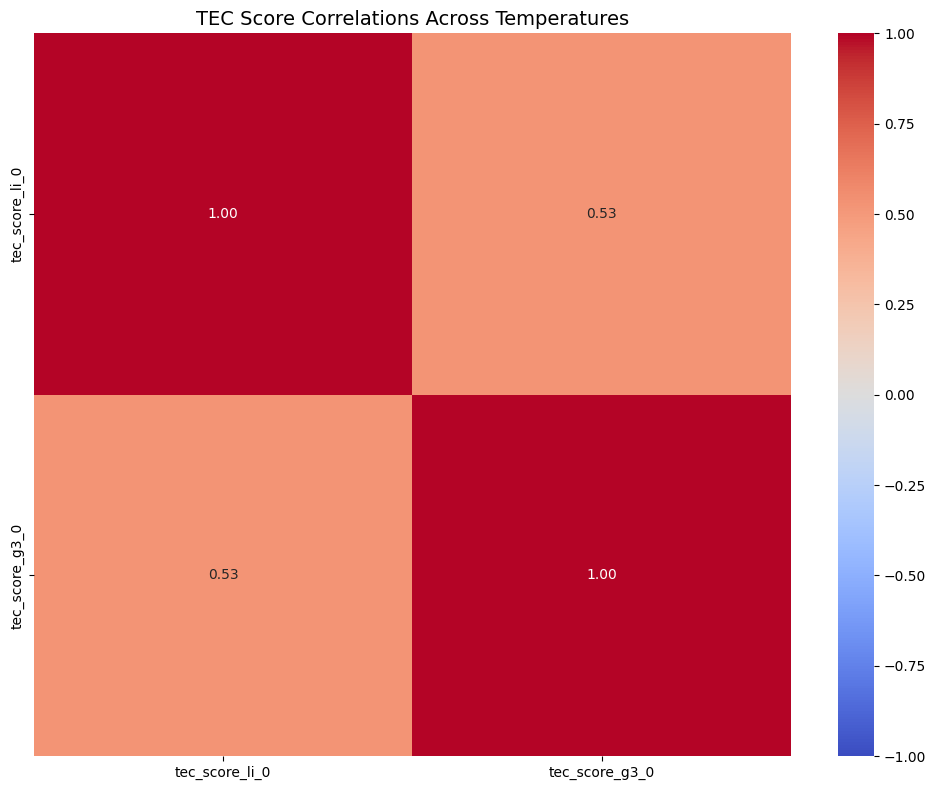


Looking for mak score columns (excluding _rev)


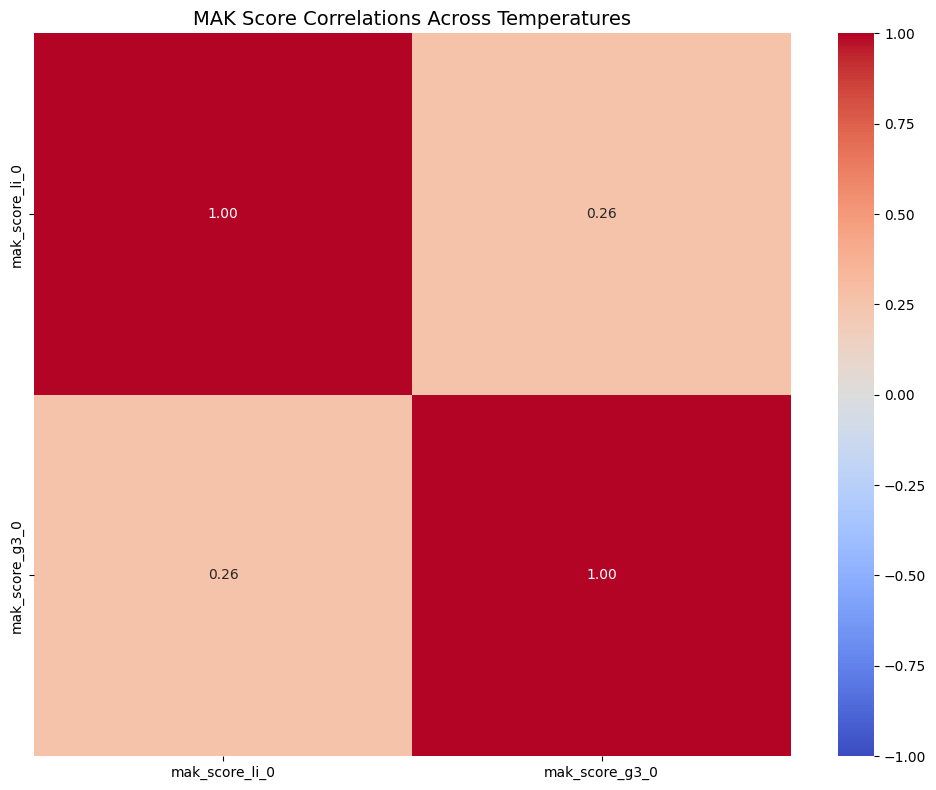


Looking for dow score columns (excluding _rev)


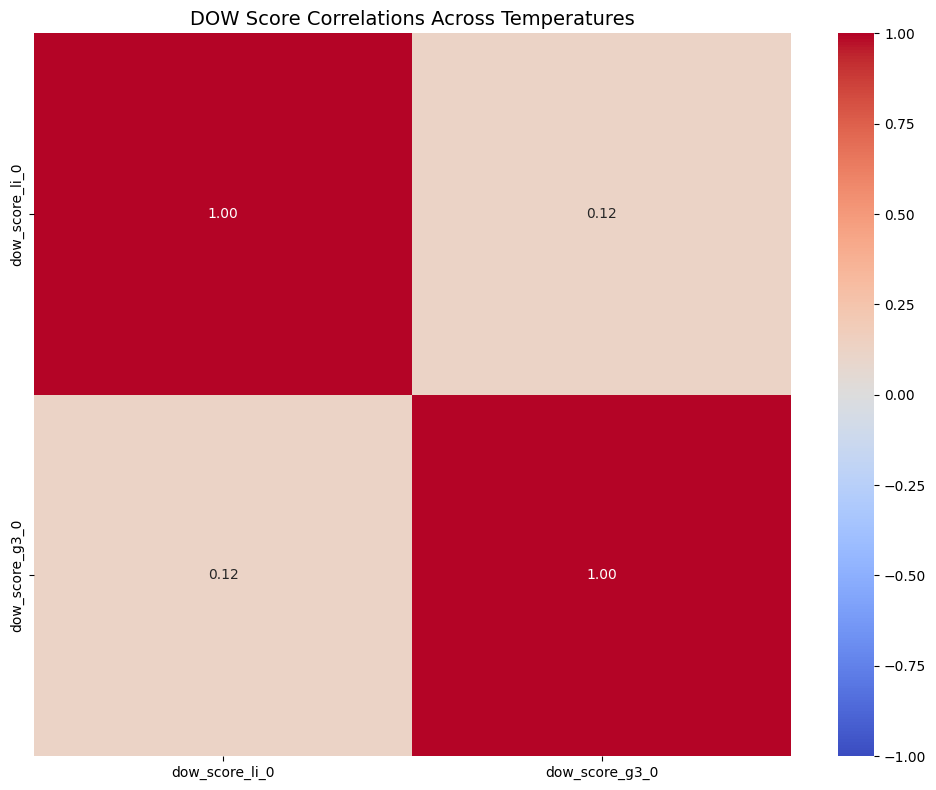


Looking for mar score columns (excluding _rev)


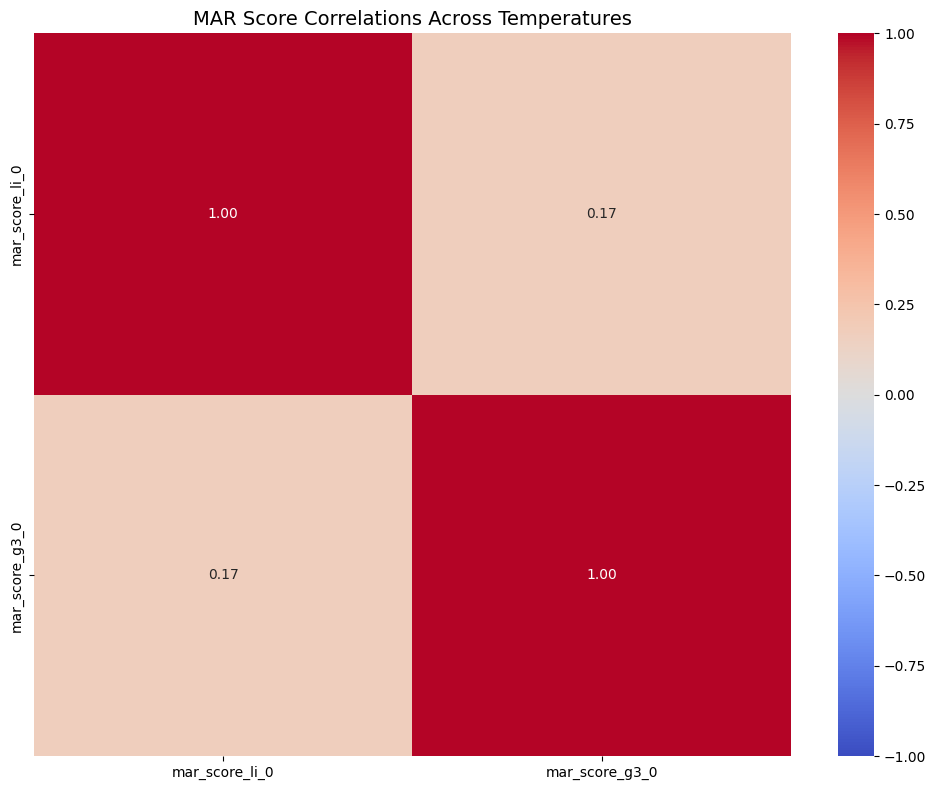


Looking for nov score columns (excluding _rev)


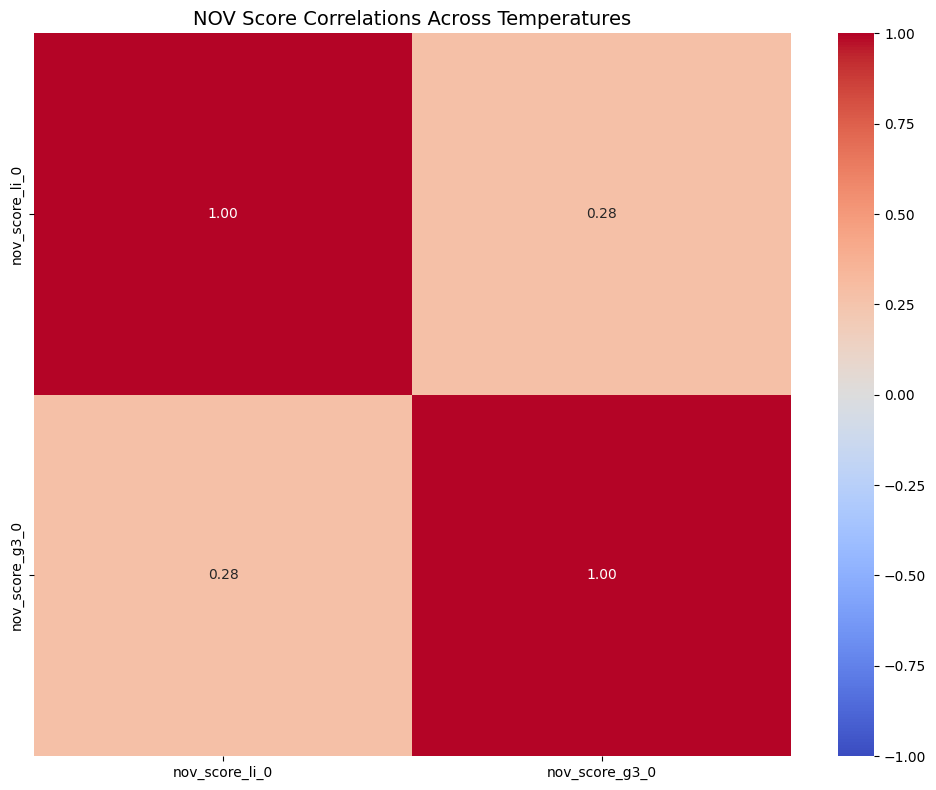


Looking for via score columns (excluding _rev)


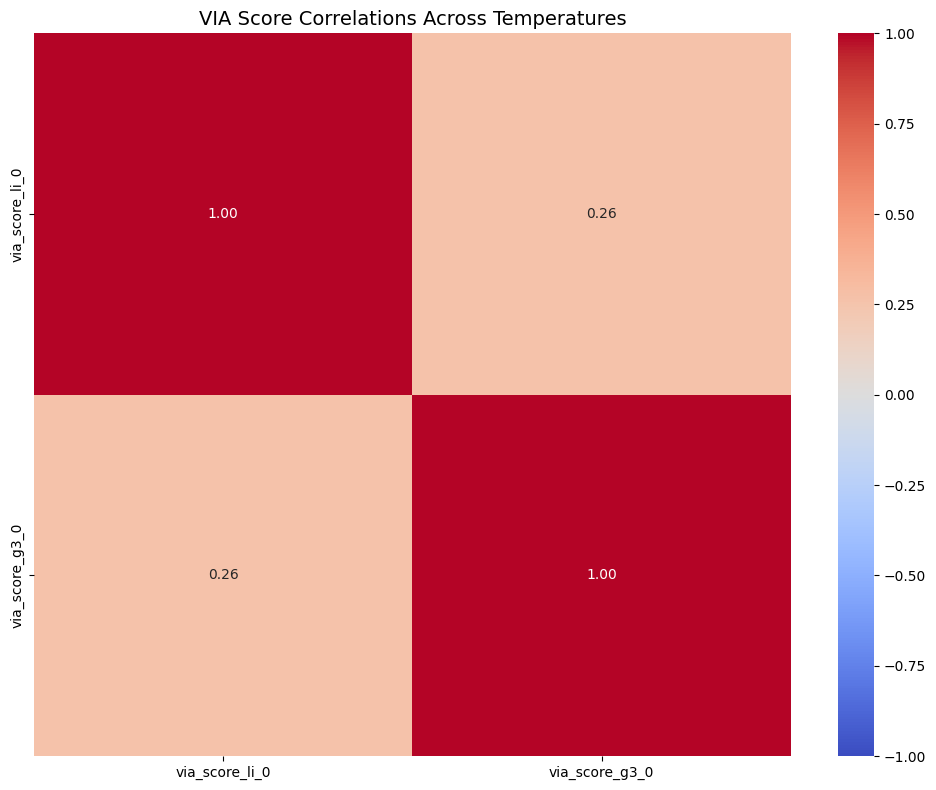


Looking for atr score columns (excluding _rev)


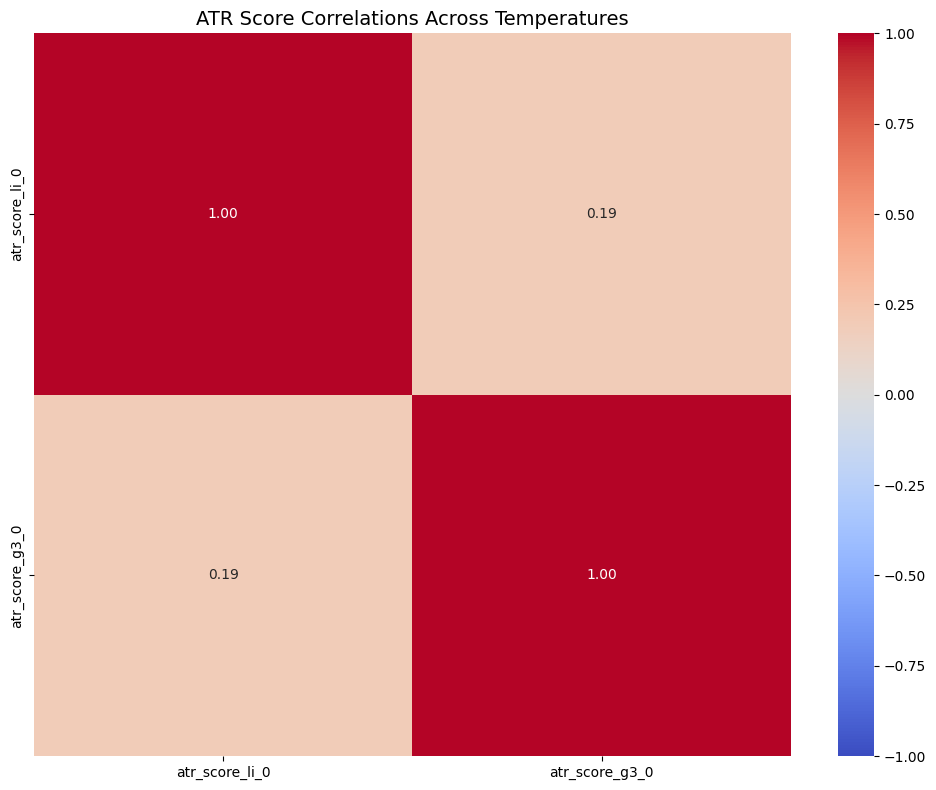

In [17]:
def plot_score_correlations(merged_models, score_prefix="sty"):
    """
    Plot correlations for a specific score type across different temperatures
    
    Parameters:
    - merged_models: dict with column names as keys and Series as values
    - score_prefix: score prefix like "sty", "tec", "mak", etc.
    """
    print(f"Looking for {score_prefix} score columns (excluding _rev)")
    
    # Find all score columns for this prefix that DON'T have '_rev'
    score_columns = []
    for col_name in merged_models.keys():
        if col_name.startswith(f"{score_prefix}_score_") and '_rev' not in col_name:
            score_columns.append(col_name)
    
    # Create DataFrame with all score series, ensuring they're numeric
    df_list = []
    for col in score_columns:
        series = merged_models[col]
        # Convert to numeric, coercing errors to NaN
        series = pd.to_numeric(series, errors='coerce')
        df_list.append(series.rename(col))
    
    combined_df = pd.concat(df_list, axis=1)
    
    # Drop rows with all NaN
    combined_df = combined_df.dropna(how='all')

    # Compute correlation
    corr = combined_df.corr()
    
    # Plot
    plt.figure(figsize=(10, 8))
    
    # Extract temperature for labels
    labels = []
    for col in score_columns:
        if 'temp' in col:
            # Extract temperature part (e.g., "1_2" from "sty_score_l_0_4")
            temp_part = col.split('_')[-2] + '_' + col.split('_')[-1]
            labels.append(temp_part)
        else:
            labels.append(col)
    
    sns.heatmap(corr, 
               annot=True, 
               fmt=".2f", 
               cmap="coolwarm",
               vmin=-1, vmax=1,
               cbar=True,
               xticklabels=labels,
               yticklabels=labels,
               annot_kws={'size': 10})
    
    plt.title(f"{score_prefix.upper()} Score Correlations Across Temperatures", fontsize=14)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()
    
    return combined_df, corr

# Plot correlations for each score type across temperatures
score_prefixes = ['sty', 'tec', 'mak', 'dow', 'mar', 'nov', 'via', 'atr']

for prefix in score_prefixes:
    print("\n" + "="*50)
    df, corr = plot_score_correlations(dr_scores, score_prefix=prefix)

## Statistics

In [18]:
# Select all score columns automatically (excluding those with 'rev')
score_cols = [col for col in dr_scores.columns if 'score' in col and '_rev' not in col]

print(f"Found {len(score_cols)} score columns")

# Melt to long format
long_scores = dr_scores.melt(
    id_vars=['id', 'masked'],
    value_vars=score_cols,
    var_name='model_full',
    value_name='score'
)

# Drop missing scores
long_scores = long_scores.dropna(subset=['score'])

# Extract model variant and temperature from column names like "sty_score_l_0_4"
def extract_model_info(col_name):
    # Split by underscore
    parts = col_name.split('_')
    
    # Format: [prefix, 'score', variant, temperature_parts...]
    # e.g., ['sty', 'score', 'l', '1', '2']
    
    if len(parts) >= 4:
        variant = parts[2]  # l, li, m, mi, g3
        
        # Temperature is everything after the variant
        if len(parts) == 4:
            # Format: sty_score_l_0 -> ['sty', 'score', 'l', '0']
            temp = parts[3]
        else:
            # Format: sty_score_l_0_4 -> ['sty', 'score', 'l', '1', '2']
            temp = '_'.join(parts[3:])
    else:
        variant = 'unknown'
        temp = 'unknown'
    
    return pd.Series({'model_variant': variant, 'temperature': temp})

# Extract model info
model_info = long_scores['model_full'].apply(extract_model_info)
long_scores = pd.concat([long_scores, model_info], axis=1)

# Create combined model_temp column
long_scores['model_temp'] = long_scores['model_variant'] + '_' + long_scores['temperature']

print("\n" + "="*60)
print("STATISTICS BY MODEL AND TEMPERATURE COMBINATION")
print("="*60)

# Statistics per model and temperature
stats_by_model_temp = long_scores.groupby('model_temp')['score'].agg([
    'count', 'mean', 'std', 'min', 'max', 'median'
]).round(2)

# Add quartiles
quartiles = long_scores.groupby('model_temp')['score'].quantile([0.25, 0.75]).unstack()
stats_by_model_temp['25%'] = quartiles[0.25].round(2)
stats_by_model_temp['75%'] = quartiles[0.75].round(2)

# Reorder columns
stats_by_model_temp = stats_by_model_temp[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max']]

# Sort by model_temp
stats_by_model_temp = stats_by_model_temp.sort_index()

print(stats_by_model_temp)

Found 16 score columns

STATISTICS BY MODEL AND TEMPERATURE COMBINATION
            count  mean   std  min  25%  median  75%  max
model_temp                                               
g3_0        64152  6.59  1.19  1.0  6.0     7.0  7.0  9.0
li_0        64144  5.08  2.11  1.0  3.0     5.0  7.0  9.0


In [19]:
import pandas as pd

# --------------------------
# 1. Drop columns containing 'rev'
# --------------------------
dr_scores = dr_scores.loc[:, ~dr_scores.columns.str.contains('rev', case=False)]
print(f"Columns after removing 'rev': {list(dr_scores.columns)}")

# --------------------------
# 2. Select score columns automatically
# --------------------------
score_cols = [col for col in dr_scores.columns if 'score' in col]
print(f"Found {len(score_cols)} score columns")

# --------------------------
# 3. Melt to long format
# --------------------------
long_scores = dr_scores.melt(
    id_vars=['id', 'masked'],
    value_vars=score_cols,
    var_name='model_full',
    value_name='score'
).dropna(subset=['score'])

# --------------------------
# 4. Extract model info safely
# --------------------------
def extract_model_info(col_name):
    parts = col_name.split('_')
    if len(parts) >= 4:
        score_type = parts[0]
        model_variant = parts[2]
        temperature = '_'.join(parts[3:])
    else:
        score_type = 'unknown'
        model_variant = 'unknown'
        temperature = 'unknown'
    return pd.Series({
        'score_type': score_type,
        'model_variant': model_variant,
        'temperature': temperature
    })

# Apply extractor
model_info = long_scores['model_full'].apply(extract_model_info)
# Assign directly to avoid duplicate columns
long_scores['score_type'] = model_info['score_type']
long_scores['model_variant'] = model_info['model_variant']
long_scores['temperature'] = model_info['temperature']

# --------------------------
# 5. Compute stats per score_type + model + temp
# --------------------------
stats = (
    long_scores
    .groupby(['score_type', 'model_variant', 'temperature'])['score']
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .round(2)
    .reset_index()
)

# Add quartiles
quartiles = (
    long_scores
    .groupby(['score_type', 'model_variant', 'temperature'])['score']
    .quantile([0.25, 0.75])
    .unstack()
    .reset_index()
    .rename(columns={0.25: '25%', 0.75: '75%'})
)

# Merge quartiles
stats = stats.merge(quartiles, on=['score_type', 'model_variant', 'temperature'])

# Reorder columns
stats = stats[
    ['score_type', 'model_variant', 'temperature',
     'count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max']
]

stats

Columns after removing 'rev': ['id', 'name', 'masked', 'sty_score_li_0', 'tec_score_li_0', 'mak_score_li_0', 'dow_score_li_0', 'mar_score_li_0', 'nov_score_li_0', 'via_score_li_0', 'atr_score_li_0', 'sty_response_li_0', 'tec_response_li_0', 'mak_response_li_0', 'dow_response_li_0', 'mar_response_li_0', 'nov_response_li_0', 'via_response_li_0', 'atr_response_li_0', 'sty_score_g3_0', 'tec_score_g3_0', 'mak_score_g3_0', 'dow_score_g3_0', 'mar_score_g3_0', 'nov_score_g3_0', 'via_score_g3_0', 'atr_score_g3_0', 'sty_response_g3_0', 'tec_response_g3_0', 'mak_response_g3_0', 'dow_response_g3_0', 'mar_response_g3_0', 'nov_response_g3_0', 'via_response_g3_0', 'atr_response_g3_0']
Found 16 score columns


,score_type,model_variant,temperature,count,mean,std,min,25%,median,75%,max
0,atr,g3,0,8019,8.02,0.35,2.0,8.0,8.0,8.0,9.0
1,atr,li,0,8018,7.81,1.22,2.0,7.0,8.0,9.0,9.0
2,dow,g3,0,8019,6.23,1.09,1.0,6.0,7.0,7.0,8.0
3,dow,li,0,8018,5.51,2.18,1.0,3.0,6.0,7.0,9.0
4,mak,g3,0,8019,5.88,1.05,1.0,5.0,6.0,7.0,8.0
5,mak,li,0,8018,3.74,1.20,1.0,3.0,3.0,4.0,8.0
6,mar,g3,0,8019,6.75,0.91,1.0,6.0,7.0,7.0,9.0
7,mar,li,0,8018,3.81,1.22,1.0,3.0,4.0,5.0,9.0
8,nov,g3,0,8019,6.60,0.70,2.0,6.0,7.0,7.0,8.0
9,nov,li,0,8018,3.24,1.46,1.0,2.0,3.0,4.0,9.0


In [ ]:
import textwrap
import pandas as pd

prefix = 'mar'

# Automatically find all matching response columns, excluding those with 'rev'
response_cols = [
    c for c in dr_scores.columns
    if c.startswith(f"{prefix}_response_") and 'rev' not in c.lower()
]

for _, row in dr_scores.iterrows():
    
    # Print masked text safely
    masked_text = row.get('masked', '')
    if pd.notna(masked_text):
        print("\n".join(textwrap.wrap(str(masked_text), width=120)))
    else:
        print("[No masked text]")
    
    print()
    
    # Print responses safely (excluding 'rev' columns)
    for col in response_cols:
        value = row.get(col, None)
        
        if pd.notna(value):
            print(f"{col}: {value}")
        else:
            print(f"{col}: [Missing]")
    
    print("\n" + "-" * 80 + "\n")